# Supplier Performance Scoring

## tl;dr

- **460 suppliers** are ranked as of **2024-12-01** using a six-month recency-weighted score.
- The average dynamic score is **67.66/100**; the latest spend-weighted portfolio score is **67.52/100**.
- **121 suppliers are improving** and **104 are deteriorating**.
- **5 suppliers** meet the replacement rule; they represent **1.1%** of trailing-12-month spend.
- **3 suppliers** qualify for strategic partnership; they represent **0.9%** of spend.

## Context & Methods

The procurement team needs one directionally consistent 0–100 score that can be ranked, trended, and converted into action. The supplied weights are used exactly: 30% on-time delivery, 20% quality, 20% risk performance, 15% cost efficiency, and 15% lead time.

Sources: `data/cleaned/vendors_clean.csv` and `data/cleaned/orders_clean.csv`.

### Key Assumptions

- VRIS is an adverse risk measure, so the scored component is `100 - VRIS`.
- Cost efficiency is 70% product-year unit-cost competitiveness and 30% invoice accuracy.
- Unit-cost competitiveness compares order COGS per unit with the median for the same product and year.
- Procurement spend measures exposure and strategic importance; it does not boost performance.
- Lead-time performance combines 80% contract adherence and 20% consistency.
- The dynamic score is a six-month exponentially weighted average with a three-month half-life.
- Improving/deteriorating means a change of at least +/-2 points between the latest and prior three-month averages.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parents[1]
sys.path.insert(0, str(ROOT))
from scripts.supplier_performance_scoring import run_pipeline, WEIGHTS
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

## Data

### 1. Load, validate, and score vendor snapshots with product-level order costs

In [2]:
result = run_pipeline()
raw = result['raw']
scored = result['scored']
ranking = result['ranking']
trends = result['trends']
checks = result['checks']
summary = result['summary']

display(checks)
print(f"Rows: {len(raw):,} | Suppliers: {raw.vendor_id.nunique():,} | "
      f"Window: {raw.snapshot_month.min().date()} to {raw.snapshot_month.max().date()}")

,check,passed,exceptions,severity_if_failed
0,Required columns present,True,0,Critical
1,Unique vendor-month grain,True,0,Critical
2,Required fields complete,True,0,High
3,Core scores within 0-100,True,0,High
4,Lead-time denominators positive,True,0,High
5,Procurement spend non-negative,True,0,High
6,Product-year cost benchmark coverage,True,0,High


Rows: 22,080 | Suppliers: 460 | Window: 2021-01-01 to 2024-12-01


### 2. Confirm the score calculation and coverage

In [3]:
print('Weights:', WEIGHTS, '| Sum:', sum(WEIGHTS.values()))
assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-12
assert scored['supplier_score'].between(0, 100).all()
assert ranking['dynamic_supplier_score'].between(0, 100).all()
display(ranking[['months_in_dynamic_window']].describe().T)

Weights: {'otd_score': 0.3, 'quality_score': 0.2, 'risk_performance_score': 0.2, 'cost_efficiency_score': 0.15, 'lead_time_score': 0.15} | Sum: 1.0


,count,mean,std,min,25%,50%,75%,max
months_in_dynamic_window,460.00,6.00,0.00,6.00,6.00,6.00,6.00,6.00


## Results

### 3. Review the supplier ranking

In [4]:
ranking_columns = ['supplier_rank', 'vendor_id', 'vendor_name', 'vendor_category',
                   'dynamic_supplier_score', 'score_change_3m', 'trend_class',
                   'supplier_risk_class', 'recommended_tier',
                   'procurement_spend_12m_usd']
display(ranking[ranking_columns].head(20))

,supplier_rank,vendor_id,vendor_name,vendor_category,dynamic_supplier_score,score_change_3m,trend_class,supplier_risk_class,recommended_tier,procurement_spend_12m_usd
0,1,VND-000040,Frazier-Flores,Logistics,81.13,9.82,Improving,High,Approved,"1,138,309.30"
1,2,VND-000409,Moore-Sanders,Raw Materials,80.98,6.74,Improving,Low,Strategic Partner,"1,034,035.17"
2,3,VND-000105,Hernandez and Sons,Packaging,79.52,-7.76,Deteriorating,High,Approved,"457,890.69"
3,4,VND-000755,"Keller, Reid and Le",Services,77.45,-2.08,Deteriorating,High,Approved,"863,189.52"
4,5,VND-001043,"Weaver, Lee and Brady",Services,76.72,5.01,Improving,High,Approved,"459,509.54"
5,6,VND-000300,King-White,Raw Materials,76.71,-0.12,Stable,High,Approved,"428,977.02"
6,7,VND-000924,Shah Group,Electronics,76.51,2.43,Improving,High,Approved,"778,820.00"
7,8,VND-000694,Larson LLC,Services,76.45,2.31,Improving,High,Approved,"631,845.15"
8,9,VND-000563,Perry Group,Electronics,76.40,3.89,Improving,Low,Strategic Partner,"743,690.89"
9,10,VND-000475,Snyder-Patterson,Services,75.94,6.99,Improving,Medium,Preferred,"369,848.84"


### 4. Compare score momentum across the portfolio

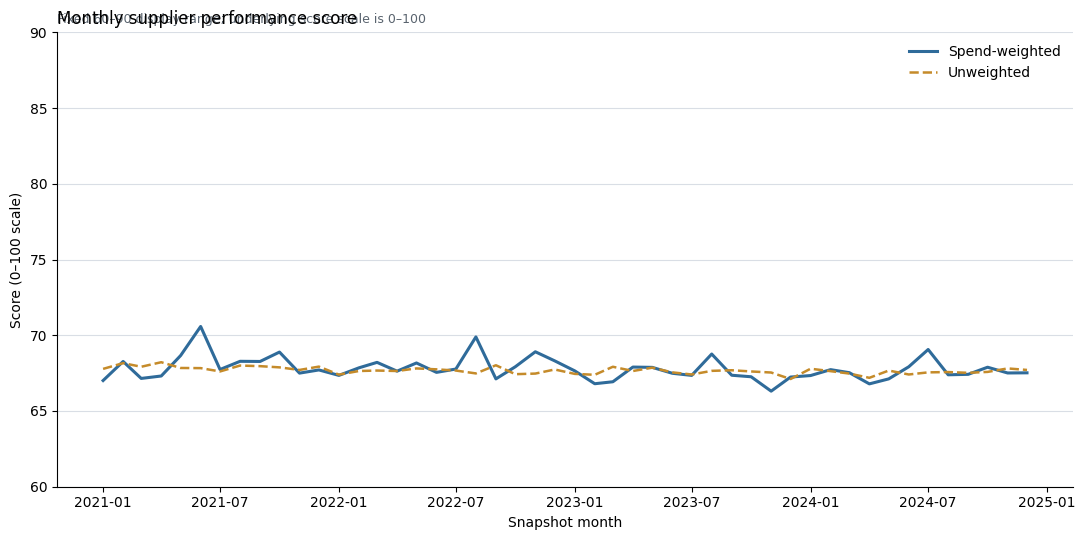

In [5]:
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(trends['snapshot_month'], trends['spend_weighted_supplier_score'],
        color='#2f6b9a', linewidth=2.2, label='Spend-weighted')
ax.plot(trends['snapshot_month'], trends['unweighted_supplier_score'],
        color='#c58b2a', linewidth=1.8, linestyle='--', label='Unweighted')
ax.set_title('Monthly supplier performance score', loc='left')
ax.text(0, 1.02, 'Fixed 60–90 display range; underlying score scale is 0–100',
        transform=ax.transAxes, color='#59636e', fontsize=9)
ax.set_ylabel('Score (0–100 scale)')
ax.set_xlabel('Snapshot month')
ax.set_ylim(60, 90)
ax.grid(axis='y', color='#d9dee5', linewidth=0.8)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### 5. Identify improving and deteriorating suppliers

In [6]:
display(ranking.nlargest(10, 'score_change_3m')[ranking_columns])
display(ranking.nsmallest(10, 'score_change_3m')[ranking_columns])

,supplier_rank,vendor_id,vendor_name,vendor_category,dynamic_supplier_score,score_change_3m,trend_class,supplier_risk_class,recommended_tier,procurement_spend_12m_usd
24,25,VND-000049,"Grant, Casey and Martinez",Raw Materials,74.19,12.46,Improving,Medium,Preferred,"1,158,435.73"
0,1,VND-000040,Frazier-Flores,Logistics,81.13,9.82,Improving,High,Approved,"1,138,309.30"
211,212,VND-000659,Bailey-Snyder,Raw Materials,67.53,8.47,Improving,Medium,Approved,"440,268.52"
45,46,VND-000625,Johnson-Deleon,Electronics,72.67,8.30,Improving,High,Approved,"449,683.42"
98,99,VND-000703,Howard-Williams,Electronics,70.36,8.08,Improving,High,Approved,"252,763.09"
165,166,VND-001022,King Group,Raw Materials,68.78,8.08,Improving,Medium,Preferred,"337,080.03"
241,242,VND-001009,Hamilton-Holt,Services,67.06,7.93,Improving,Medium,Approved,"680,994.61"
150,151,VND-000457,"Garcia, Hart and Savage",Industrial Parts,69.13,7.74,Improving,Medium,Preferred,"557,046.40"
11,12,VND-000417,"Watkins, Cole and Branch",Logistics,75.75,7.65,Improving,Low,Preferred,"670,073.80"
100,101,VND-000923,Crane-Fuller,Raw Materials,70.34,7.62,Improving,High,Approved,"1,347,850.50"


,supplier_rank,vendor_id,vendor_name,vendor_category,dynamic_supplier_score,score_change_3m,trend_class,supplier_risk_class,recommended_tier,procurement_spend_12m_usd
54,55,VND-001115,Russell-Wilson,Industrial Parts,72.31,-15.28,Deteriorating,High,Approved,"1,237,382.34"
32,33,VND-001149,Burnett-Stevens,Raw Materials,73.78,-12.23,Deteriorating,High,Approved,"2,373,807.88"
26,27,VND-001011,"Carter, Acevedo and Dennis",Industrial Parts,74.15,-12.22,Deteriorating,High,Approved,"574,500.35"
190,191,VND-000290,"Flores, Pierce and Brown",Industrial Parts,67.87,-11.44,Deteriorating,High,Approved,"1,036,026.72"
371,372,VND-000526,"Johnson, Turner and Young",Packaging,64.47,-9.62,Deteriorating,High,Approved,"321,922.24"
171,172,VND-000102,Morris-Campbell,Raw Materials,68.46,-8.95,Deteriorating,High,Approved,"807,034.14"
431,432,VND-000304,"Martinez, Davis and Mcdonald",Electronics,62.55,-8.44,Deteriorating,High,Approved,"479,194.66"
2,3,VND-000105,Hernandez and Sons,Packaging,79.52,-7.76,Deteriorating,High,Approved,"457,890.69"
108,109,VND-000760,Morton-Gonzales,Services,70.08,-6.98,Deteriorating,High,Approved,"463,041.63"
141,142,VND-000086,Deleon-Butler,Packaging,69.37,-6.58,Deteriorating,High,Approved,"7,805,375.03"


### 6. Prioritize replacement and strategic partnership decisions

In [7]:
replacement = ranking.loc[ranking['replacement_candidate'], ranking_columns]
strategic = ranking.loc[ranking['recommended_tier'].eq('Strategic Partner'), ranking_columns]
print('Replacement candidates')
display(replacement)
print('Strategic partnership candidates')
display(strategic)

Replacement candidates


,supplier_rank,vendor_id,vendor_name,vendor_category,dynamic_supplier_score,score_change_3m,trend_class,supplier_risk_class,recommended_tier,procurement_spend_12m_usd
36,37,VND-000707,"Warren, Gallegos and Berry",Industrial Parts,73.21,-2.13,Deteriorating,Critical,Replace,"1,522,885.67"
37,38,VND-001184,Williams-Roberts,Industrial Parts,73.19,-5.50,Deteriorating,Critical,Replace,"654,352.73"
113,114,VND-001129,Anderson LLC,Packaging,69.98,-6.11,Deteriorating,Critical,Replace,"262,881.61"
268,269,VND-000718,Hayes-Mcguire,Electronics,66.51,-3.18,Deteriorating,Critical,Replace,"1,404,080.15"
437,438,VND-000611,Jones and Sons,Industrial Parts,62.21,-6.07,Deteriorating,Critical,Replace,"492,367.59"


Strategic partnership candidates


,supplier_rank,vendor_id,vendor_name,vendor_category,dynamic_supplier_score,score_change_3m,trend_class,supplier_risk_class,recommended_tier,procurement_spend_12m_usd
1,2,VND-000409,Moore-Sanders,Raw Materials,80.98,6.74,Improving,Low,Strategic Partner,"1,034,035.17"
8,9,VND-000563,Perry Group,Electronics,76.40,3.89,Improving,Low,Strategic Partner,"743,690.89"
10,11,VND-000885,James-Fox,Services,75.84,5.98,Improving,Medium,Strategic Partner,"1,715,221.12"


## Takeaways

1. **Use the ranking for performance decisions, and spend for sequencing.** Spend is exposure, not a performance reward.
2. **Start replacement due diligence with the flagged candidates.** Confirm category substitutability, contractual constraints, and capacity before exiting.
3. **Offer partnership plans to the strategic candidates.** Tie longer commitments to service-level, quality, and risk-monitoring clauses.
4. **Place high-spend deteriorators on 30/60/90-day corrective-action plans.** Trend and exposure together determine urgency.
5. **Recalibrate thresholds quarterly.** Review the product-year cost benchmark and invoice-control blend against negotiated-price or should-cost data.